**ViroVision - TEM Virus image Object Detection and Classification Model - Using Faster R-CNN with ResNet-50 and FPN**

---

**Alam Rincon - https://github.com/MrRincon**

---

**Shahane, S. (2021) 'Virus Image Dataset'. Available at: https://www.kaggle.com/datasets/saurabhshahane/virus-images (Accessed: 02 February 2025). Available license at: https://creativecommons.org/licenses/by/4.0/**

# **Run once and restart the kernel. Do not run again, and continue with 'Data Directories Check-Up and Data Extraction'.**

Installing opencv, torch, torchvision and pycocotools before importing it

In [1]:
pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


# **Data Directories Check-Up and Data Extraction**




## Setting up the libraries

 Importing all the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff
import cv2
import numpy as np
import pandas as pd
import os
import csv
import json
import math
import copy
import concurrent.futures

## Directories, Images and Files Check-Up

Defining the Dataset, Train, Validation and Test Paths

In [2]:
# Sorting out the paths to the data extracted from Kaggle at: https://www.kaggle.com/datasets/saurabhshahane/virus-images
DATASETS_PATH = './context_virus_RAW'

TRAIN_PATH = os.path.join(DATASETS_PATH, 'train')
VALIDATION_PATH = os.path.join(DATASETS_PATH, 'validation')
TEST_PATH = os.path.join(DATASETS_PATH, 'test')

In [3]:
# Getting the virus names from each folder to use as labels for classification
def get_virus_names(*folders):
    virus_names = set()
    for folder in folders:
        if os.path.exists(folder):
          virus_names.update(os.listdir(folder))
    return sorted(virus_names)

VIRUSES = get_virus_names(TRAIN_PATH, VALIDATION_PATH, TEST_PATH)
print("--VIRUSES--")
for index, virus in enumerate(VIRUSES):
    if index == len(VIRUSES) - 1:
        print(f"{virus}")
    else:
        print(f"{virus}, ", end="")
    if (index + 1) % 5 == 0 and index != len(VIRUSES) - 1:
        print("")

--VIRUSES--
Adenovirus, Astrovirus, CCHF, Cowpox, Dengue, 
Ebola, Guanarito, Influenza, LCM, Lassa, 
Machupo, Marburg, Nipah virus, Norovirus, Orf, 
Papilloma, Pseudocowpox, Rift Valley, Rotavirus, Sapovirus, 
TBE, WestNile


Function to check if the virus folders exist in all datasets partitions

In [4]:
# Checking the virus folders and prompting warnings if anything is missing 
def check_virus_folders(dataset, viruses):
    found_folders = [v for v in viruses if os.path.exists(os.path.join(dataset, v))]
    missing_folders = [v for v in viruses if not os.path.exists(os.path.join(dataset, v))]
    
    if missing_folders:
        print(f"Warning: Missing folders in {dataset}: {missing_folders}")
    
    total_found = len(found_folders)
    total_missing = len(missing_folders)
    return not bool(missing_folders), total_found

In [5]:
train_ok, train_virus_found = check_virus_folders(TRAIN_PATH, VIRUSES)
validation_ok, validation_virus_found= check_virus_folders(VALIDATION_PATH, VIRUSES)
test_ok, test_virus_found = check_virus_folders(TEST_PATH, VIRUSES)
if train_ok and validation_ok and test_ok:
    print("All virus folders found in train, validation, and test datasets.")
else:
    print("Some virus folders were not found or empty.")

All virus folders found in train, validation, and test datasets.


Bar plot to display the amount of viruses found in each dataset

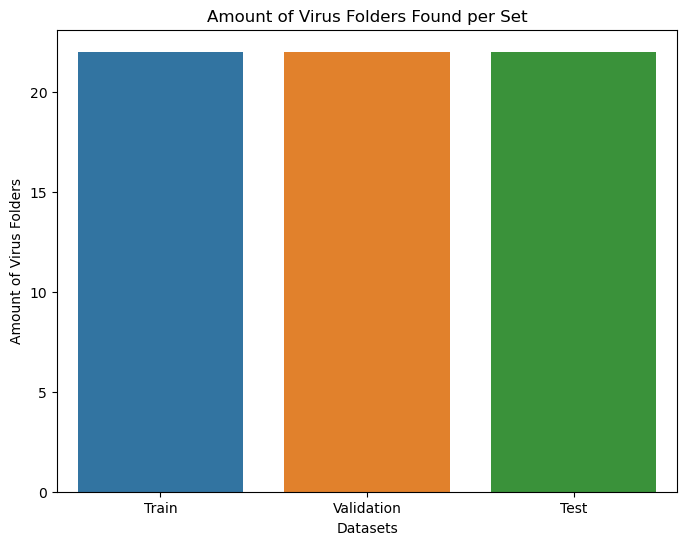

In [6]:
# Plotting the amount of viruses found in each dataset
plt.figure(figsize=(8, 6))
xValues = np.array(["Train", "Validation", "Test"])
yValues = np.array([train_virus_found, validation_virus_found, test_virus_found])
sns.barplot(x=xValues, y=yValues)
plt.title("Amount of Virus Folders Found per Set")
plt.xlabel("Datasets")
plt.ylabel("Amount of Virus Folders")
plt.show()

Function to check that the transmission electron microscopy (TEM) images have their respective tags(.csv) and particle positions(.txt)

In [7]:
# Checking for the TEM Images to confirm their existence along with the respective metadata and particle positions
def check_TEM_files(dataset, viruses):
    dataset_folder = os.path.basename(dataset)
    print(f"Checking {dataset_folder} dataset...")
    total_tif_per_folder = []
    for virus in viruses:
        virus_dir = os.path.join(dataset, virus)
        tif_files = [f for f in os.listdir(virus_dir) if f.endswith(".tif")]
        total_tif_per_folder.append(len(tif_files))
    
        particle_positions_path = os.path.join(virus_dir, 'particle_positions')
        tags_path = os.path.join(virus_dir, 'tags')
        particle_postions_exist = os.path.exists(particle_positions_path)
        tags_exist = os.path.exists(tags_path)
    
        if not particle_postions_exist or not tags_exist:
            print(f"Warning: Missing .txt or .csv file for {virus_dir}")
            return False, total_tif_per_folder
    
        for filename in tif_files:
            base_name = os.path.splitext(filename)[0]
            txt_file = os.path.join(particle_positions_path, base_name + '_particlepositions.txt')
            csv_file = os.path.join(tags_path, base_name + '.tif_tags.csv')
    
            if not os.path.exists(txt_file):
                print(f"Error: Missing .txt file for {txt_file}")
                return False, total_tif_per_folder
            if not os.path.exists(csv_file):
                print(f"Error: Missing .csv file for {csv_file}")
                return False, total_tif_per_folder
    return True, total_tif_per_folder

train_TEM_info, train_tif_count = check_TEM_files(TRAIN_PATH, VIRUSES)
validation_TEM_info, validation_tif_count = check_TEM_files(VALIDATION_PATH, VIRUSES)
test_TEM_info, test_tif_count = check_TEM_files(TEST_PATH, VIRUSES)
print()
if train_TEM_info and validation_TEM_info and test_TEM_info:
    print("All the TEM files, with tags and particle positions were found.")
else:
    print("Some the TEM files, with tags and particle positions were not found.")

Checking train dataset...
Checking validation dataset...
Checking test dataset...

All the TEM files, with tags and particle positions were found.


Calculating the tif amount of files and the quantiles for each dataset

In [8]:
#  Acummulating the values for each stage of the project and adquiring the rounded values from the quantiles 
all_tif_counts = train_tif_count + validation_tif_count + test_tif_count
dataset_labels = ["Train"] * len(train_tif_count) + ["Validation"] * len(validation_tif_count) + ["Test"] * len(test_tif_count)
train_quantiles = np.quantile(train_tif_count, [0.25, 0.5, 0.75])
validation_quantiles = np.quantile(validation_tif_count, [0.25, 0.5, 0.75])
test_quantiles = np.quantile(test_tif_count, [0.25, 0.5, 0.75])

rounded_train_quantiles = [round(q) for q in train_quantiles]
rounded_validation_quantiles = [round(q) for q in validation_quantiles]
rounded_test_quantiles = [round(q) for q in test_quantiles]

Displaying the data analysis and quantile values for the amount of TIF images per folder in each dataset,

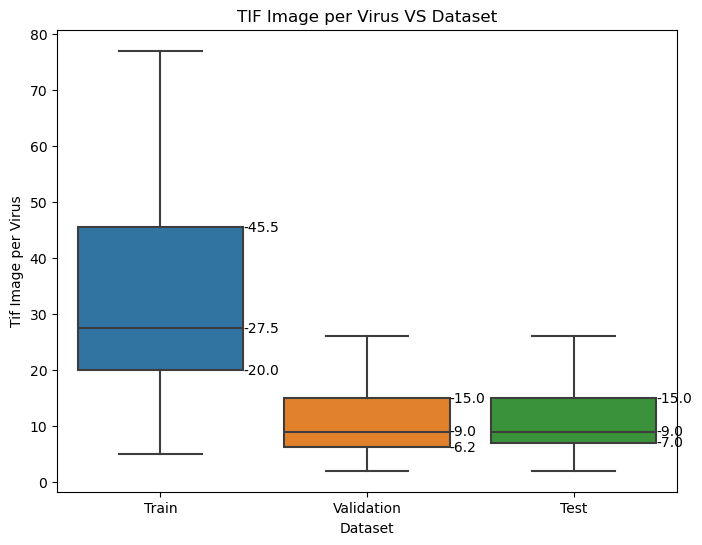

Rounded Median for the data to the nearest non-decimal value
Training Q1 =  20 , Q2 =  28 , Q3 =  46
Validation Q1 =  6 , Q2 =  9 , Q3 =  15
Test Q1 =  7 , Q2 =  9 , Q3 =  15


In [9]:
# Plotting the quantile values of the TIF Images per Virus in each Dataset
plt.figure(figsize=(8,6))
xValues = np.array(dataset_labels)
yValues = np.array(all_tif_counts)
ax = sns.boxplot(x=xValues, y=yValues)
plt.title("TIF Image per Virus VS Dataset")
plt.xlabel("Dataset")
plt.ylabel("Tif Image per Virus")
for index, quantile in enumerate(train_quantiles):
    ax.text(0.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
for index, quantile in enumerate(validation_quantiles):
    ax.text(1.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
for index, quantile in enumerate(test_quantiles):
    ax.text(2.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
plt.show()
print("Rounded Median for the data to the nearest non-decimal value")
print("Training Q1 = ", rounded_train_quantiles[0], ", Q2 = ", rounded_train_quantiles[1], ", Q3 = ", rounded_train_quantiles[2])
print("Validation Q1 = ", rounded_validation_quantiles[0], ", Q2 = ", rounded_validation_quantiles[1], ", Q3 = ", rounded_validation_quantiles[2])
print("Test Q1 = ", rounded_test_quantiles[0], ", Q2 = ", rounded_test_quantiles[1], ", Q3 = ", rounded_test_quantiles[2])

Defining the amount of images I should have per folder in the training set by using the median

In [10]:
# Defining the Q3 value to use in the Augmentation process
train_q3 = rounded_train_quantiles[2]
print(f"Third quantile value: {train_q3}")

Third quantile value: 46


## Extracting and normalising the data

Function to One-Hot Encode the name of the viruses and use them as labels

In [11]:
# One_hot encoding the name of the viruses to reduce noice and use them as labels 
def one_hot_encode_viruses(viruses):
    virus_to_index = {virus: index for index, virus in enumerate(viruses)}
    one_hot_viruses_dict = {virus: np.eye(len(viruses), dtype=int)[index] for virus, index in virus_to_index.items()}
    return one_hot_viruses_dict

Function to resize the pixels of the TEM images and normalise the values

In [12]:
# Resizing using OpenCV library (cv2) and normalising the TEM images to reduce noice
def resize_normalise_tem_image(image_path, target_size=(224, 224)):
    try:
        img = tiff.imread(image_path)
        if not isinstance(img, np.ndarray):
            raise ValueError("Image data is not in a supported format.")
        if img.dtype != np.uint8:
            img = (img - img.min()) / (img.max() - img.min()) * 255
            img = img.astype(np.uint8)
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        normalised_img = resized_img.astype(np.float32) / 255.0

        return normalised_img

    except Exception as e:
        print(f"An error occurred while processing {image_path}: {e}")

        return None

Function to extract the amount and positions of particles that are part of the image

In [13]:
# Extracting the particle positions for each image
# Reallocating the particle to the resized image
# Normalising the pixel location values to reduce noice
def extract_normalise_particle_positions(particle_positions_path, target_size=(224, 224)):
    amount_of_particles = 0
    normalised_positions = []
    with open(particle_positions_path, 'r') as file:
        lines = file.readlines()
    
        original_width, original_height = map(int, lines[1].strip(). split(';'))
        for line in lines[2:]:
            if 'particleposition' in line:
                amount_of_particles += 1
            else:
                try:
                    x, y = map(int, line.strip().split(';'))
                    normalised_x = float((x / original_width) * target_size[0])
                    normalised_y = float((y / original_height) * target_size[1])
                    normalised_positions.append((normalised_x, normalised_y))
        
                except ValueError:
                    continue
    
    return amount_of_particles, normalised_positions

Function to extract only the relevant tags for the machine learning model to train, validate and test

In [14]:
# Extracting the relevant metadata
# Normalising the values used for object detection and segmentation
def extract_normalise_relevant_tags(relevant_tags_path, target_size=(224,224)):
    metadata = pd.read_csv(relevant_tags_path,delimiter =';', header=None, index_col=None)
    keys = metadata[0].tolist()
    values = metadata[1].tolist()
    
    try:
        original_width = int(values[keys.index('Width')])
        original_height = int(values[keys.index('Heigt')])
    
        grid_x = float(str(values[keys.index('GridposX')]).replace(',', '.'))
        grid_y = float(str(values[keys.index('GridposY')]).replace(',', '.'))
        grid_z = float(str(values[keys.index('GridposZ')]).replace(',', '.'))
        x_scale = float(str(values[keys.index('Xscale')]).replace(',', '.'))
        y_scale = float(str(values[keys.index('Yscale')]).replace(',', '.'))
        acc_voltage = int(values[keys.index('AccVoltage')])
        defocus = int(values[keys.index('Defocus')])
        magnification = int(values[keys.index('Magnification')])
        tilt_x = float(str(values[keys.index('TiltX')]).replace(',', '.'))
        tilt_y = float(str(values[keys.index('TiltY')]).replace(',', '.'))
    
        normalised_x_scale = x_scale * (target_size[0] / original_width)
        normalised_y_scale = y_scale * (target_size[1] / original_height)
    
    except ValueError:
        raise ValueError("Error in parsing metadata. Check for missing or incorrectly formatted values.")
    except KeyError:
        raise KeyError("Error: One or more metadata keys are missing.")
    return (grid_x, grid_y, grid_z, normalised_x_scale, normalised_y_scale, acc_voltage, defocus, magnification, tilt_x, tilt_y)

Function to process the virus data

In [15]:
# Processing the virus data
# Calling different functions to extract the data, metadata, and particle positions in the best possible format
def process_virus_data(virus, dataset, one_hot_viruses):
    virus_dir = os.path.join(dataset, virus)
    virus_data =[]
    
    with os.scandir(virus_dir) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.endswith(".tif"):
                base_name = os.path.splitext(entry.name)[0]
                image_path = entry.path
                particle_positions_path = os.path.join(virus_dir, 'particle_positions', base_name + '_particlepositions.txt')
                tags_path = os.path.join(virus_dir, 'tags', base_name + '.tif_tags.csv')
        
                if not os.path.exists(particle_positions_path) and os.path.exists(tags_path):
                    print(f"Missing .txt file for {particle_positions_path}")
        
                try:
                    img = resize_normalise_tem_image(image_path)
                    amount_of_particles, particle_positions = extract_normalise_particle_positions(particle_positions_path)
                    grid_x, grid_y, grid_z, x_scale, y_scale, acc_voltage, defocus, magnification, tilt_x, tilt_y = extract_normalise_relevant_tags(tags_path)
                    virus_data.append({
                        "image": img,
                        "width": 224,
                        "height": 224,
                        "virus_label": one_hot_viruses[virus],
                        "amount_of_particles": amount_of_particles,
                        "particle_positions": particle_positions,
                        "grid_x": grid_x,
                        "grid_y": grid_y,
                        "grid_z": grid_z,
                        "x_scale": x_scale,
                        "y_scale": y_scale,
                        "acc_voltage": acc_voltage,
                        "defocus": defocus,
                        "magnification": magnification,
                        "tilt_x": tilt_x,
                        "tilt_y": tilt_y
                    })
                except Exception as e:
                    print(f"Error processing {entry.name}: {e}")
    
    return virus_data

Function to multiprocess the extraction of the training, validation and testing data

In [16]:
# Multiprocessing the data extraction to accelerate the process
# Organising the data extracted by the corresponding label
def multiprocessed_data_extraction(dataset, viruses):
    current_dataset = os.path.basename(dataset)
    print(f"Extracting data from {current_dataset} dataset...")
    all_data = []
    one_hot_viruses = one_hot_encode_viruses(viruses)
    
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_virus_data, virus, dataset, one_hot_viruses): virus for virus in viruses}
        for future in concurrent.futures.as_completed(futures):
            all_data.extend(future.result())
    
    organised_data = {}
    
    for item in all_data:
        virus_label = tuple(item["virus_label"])
        if virus_label not in organised_data:
            organised_data[virus_label] = []
        organised_data[virus_label].append(item)
    
    
    return organised_data

train_data = multiprocessed_data_extraction(TRAIN_PATH, VIRUSES)
validation_data = multiprocessed_data_extraction(VALIDATION_PATH, VIRUSES)
test_data = multiprocessed_data_extraction(TEST_PATH, VIRUSES)

print("Processed Data extraction for all the datasets completed.")

Extracting data from train dataset...
Extracting data from validation dataset...
Extracting data from test dataset...
Processed Data extraction for all the datasets completed.


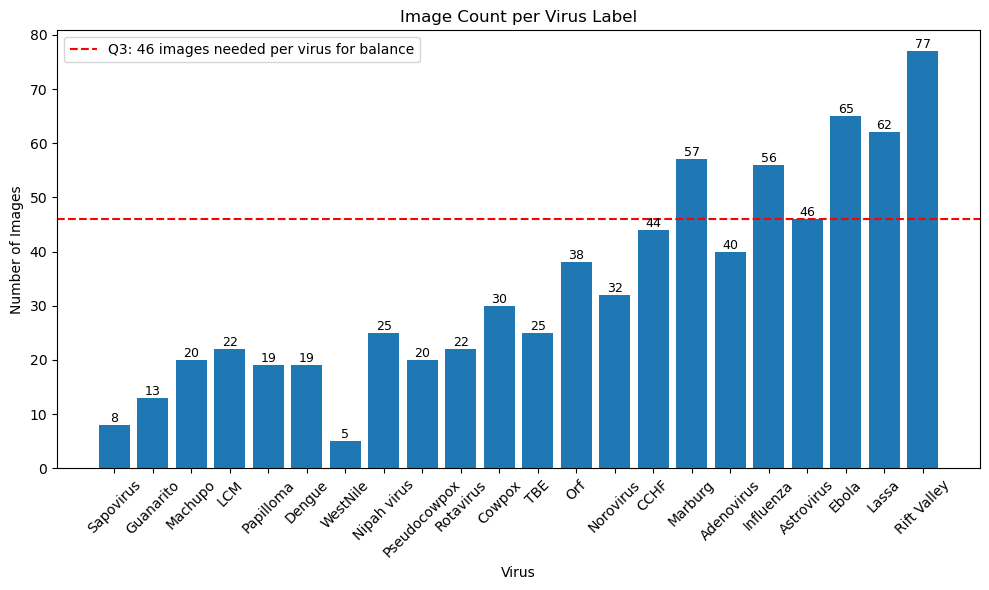

In [17]:
# Printing the amount of images extracted per label 
virus_counts = {}
for virus_label in train_data:
    virus_index = np.argmax(virus_label)
    virus_name = VIRUSES[virus_index]
    if virus_name not in virus_counts:
        virus_counts[virus_name] = 0
    virus_counts[virus_name] += len(train_data[virus_label])

plt.figure(figsize=(10, 6))
bars = plt.bar(virus_counts.keys(), virus_counts.values())
plt.xlabel("Virus")
plt.ylabel("Number of Images")
plt.title("Image Count per Virus Label")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), 
             ha='center', va='bottom', fontsize=9)
plt.axhline(train_q3, color='red', linestyle='--', label=f'Q3: {int(train_q3)} images needed per virus for balance')
plt.legend()
plt.tight_layout()
plt.show()